In [1]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

In [2]:
# @nb.njit
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
L = 1.0
Nx = 100
dx = L / Nx
phi = 0.2
u = 1e-6
mu_w = 1e-3
mu_g = 1e-5
S_wc = 0.2
S_gr = 0.1

S_inicial = 0.2
S_left = 1.0

In [4]:
# @nb.njit
def S_n(S):
    return (S - S_wc) / (1 - S_wc - S_gr)

# @nb.njit
def k_rw(S):

    return ((S - S_wc) / (1 - S_wc - S_gr)) ** 4
    
    Sn = S_n(S)
    return Sn**4

# @nb.njit
def k_rg(S):

    return ((1 - S - S_gr) / (1 - S_wc - S_gr)) ** 2
    
    Sn = S_n(S)
    return (1 - Sn)**2

# @nb.njit
def f_w(S):
    
    lambda_w = k_rw(S) / mu_w
    lambda_g = k_rg(S) / mu_g
    return lambda_w / (lambda_w + lambda_g)
                       
    krw = k_rw(S)
    krg = k_rg(S)
    return krw / (krw + (mu_w/mu_g) * krg)

# @nb.njit
def f(S):
    return u * f_w(S)

# @nb.njit
def rhs(t, y):
    F = np.empty(y.shape[0] + 1, dtype=np.float32)
    F[0] = f(S_left)
    F[1:] = f(y)

    return -(F[1:] - F[:-1]) / (phi * dx)
    

In [5]:
xs = np.linspace(dx/2, L - dx/2, Nx)
S0 = np.full(xs.shape[0], S_inicial)
dt = 10.0
T_max = 150000

ts, Ss = ODE_system_solver(rhs, S0, 0, T_max, dt)

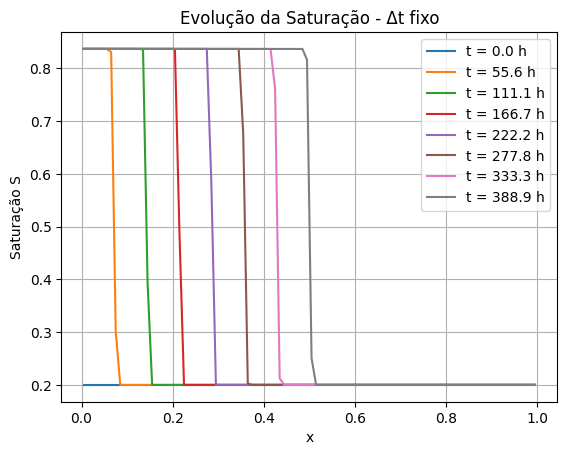

In [6]:
for t, S in zip(ts[::2000], Ss[::2000]):
    plt.plot(xs, S, label=f't = {t/360:.1f} h')

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
ts /= np.max(ts)

In [18]:
N = 3000 # quantos pontos vamos ter a solução exata para treino
N_contorno = N // 10 # 10% pontos de contorno
N_inicial = N // 10 # 10% condição inicial
N_colocacao = N - N_contorno - N_inicial

idxs_t_contorno = np.random.randint(low=0, high=ts.shape[0], size=N_contorno)
idxs_t_inicial = np.zeros(N_inicial, dtype=np.int32) # t == 0 <=> idx == 0 nesse caso
idxs_t_colocacao = np.random.randint(low=0, high=ts.shape[0], size=N_colocacao)

idxs_x_contorno = np.zeros(N_contorno, dtype=np.int32) # x == 0 <=> idx == 0 nesse caso
idxs_x_inicial = np.random.randint(low=0, high=xs.shape[0], size=N_inicial)
idxs_x_colocacao = np.random.randint(low=0, high=xs.shape[0], size=N_colocacao)

# X[:, 0] -> t (primeira coluna)
# X[:, 1:] -> x (resto)
X_contorno = torch.tensor(np.stack((ts[idxs_t_contorno], xs[idxs_x_contorno]), axis=1), dtype=torch.float32)
X_inicial = torch.tensor(np.stack((ts[idxs_t_inicial], xs[idxs_x_inicial]), axis=1), dtype=torch.float32)
X_colocacao = torch.tensor(np.stack((ts[idxs_t_colocacao], xs[idxs_x_colocacao]), axis=1), dtype=torch.float32)

y_contorno = torch.tensor(Ss[idxs_t_contorno, idxs_x_contorno], dtype=torch.float32)
y_inicial = torch.tensor(Ss[idxs_t_inicial, idxs_x_inicial], dtype=torch.float32)
y_colocacao = torch.tensor(Ss[idxs_t_colocacao, idxs_x_colocacao], dtype=torch.float32)

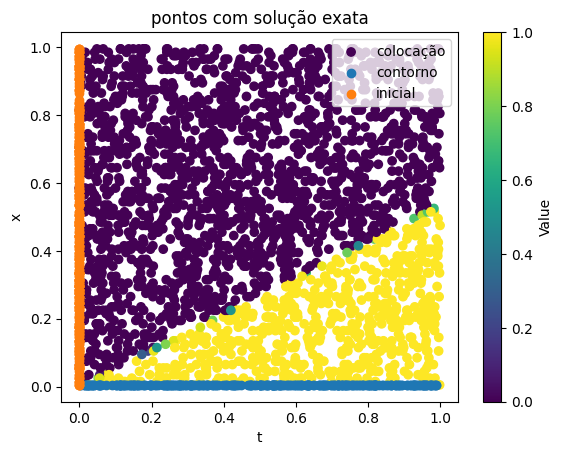

In [19]:
plt.scatter(X_colocacao[:, 0], X_colocacao[:, 1:], c=y_colocacao, cmap="viridis", label="colocação")
plt.scatter(X_contorno[:, 0], X_contorno[:, 1:], label="contorno")
plt.scatter(X_inicial[:, 0], X_inicial[:, 1:], label="inicial")
plt.xlabel('t')
plt.ylabel('x')
plt.title('pontos com solução exata')
plt.colorbar(label='Value')
plt.legend()
plt.show()

In [20]:
lambda_1 = 1.0 # ?

In [21]:
def pinn_loss(X_batch, y_batch, y_batch_contorno, y_batch_inicial):

    dy_dX = torch.autograd.grad(y_batch, X_batch, grad_outputs=torch.ones_like(y_batch), create_graph=True)[0]

    f_val = f(y_batch)
    df_dy = torch.autograd.grad(f_val, y_batch, grad_outputs=torch.ones_like(y_batch), create_graph=True)[0]
    
    dy_dt = dy_dX[:, 0]
    dy_dx = dy_dX[:, 1:]
    df_dx = df_dy * dy_dx # regra da cadeia

    L_f = torch.mean((phi * dy_dt + df_dx) ** 2)
    L_b1 = torch.mean((y_batch_inicial - 0.2) ** 2)
    L_b2 = torch.mean((y_batch_contorno - 1.0) ** 2)

    L_PINN = L_f + lambda_1 * (L_b1 + L_b2)

    return L_PINN

In [27]:
class Generator(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1) # scalar output


G = Generator(2, 64)
D = Critic(2 + 1, 64)

In [28]:
n_iter = 10000

batch_size = 128
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

lambda_gp = 0.5
n_critic = 3
lr = 1e-5
G_optimizer_GAN = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9)) # usa os betas recomendados para WGAN-GP
G_optimizer_PINN = optim.Adam(G.parameters(), lr=lr)
D_optimizer = optim.Adam(D.parameters(), lr=lr * n_critic, betas=(0.0, 0.9))

In [29]:
for it in range(n_iter):

    # replace=False pra não pegar o mesmo ponto duas vezes
    idxs_batch_contorno = np.random.choice(N_contorno, size=batch_contorno, replace=False)
    idxs_batch_inicial = np.random.choice(N_inicial, size=batch_inicial, replace=False)
    idxs_batch_colocacao = np.random.choice(N_colocacao, size=batch_colocacao, replace=False)

    # separar em contorno, inicial e colocação só ajuda na hora de calcular o L_PINN
    X_batch_contorno = X_contorno[idxs_batch_contorno]
    X_batch_inicial = X_inicial[idxs_batch_inicial]
    X_batch_colocacao = X_colocacao[idxs_batch_colocacao]
    
    # pro resto dos calculos, junta tudo numa coisa só que tudo fica melhor
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)

    # mesma coisa com o y
    y_batch_contorno = y_contorno[idxs_batch_contorno].view(-1, 1)
    y_batch_inicial = y_inicial[idxs_batch_inicial].view(-1, 1)
    y_batch_colocacao = y_colocacao[idxs_batch_colocacao].view(-1, 1)
    y_batch = torch.cat((y_batch_contorno, y_batch_inicial, y_batch_colocacao), dim=0)

    
    
    # GRADIENT PENALTY DO DISCRIMINADOR
    y_fake = G(X_batch)
    
    eps = torch.rand((y_fake.shape[0], 1))

    y_hat = eps * y_batch + (1 - eps) * y_fake.detach()
    y_hat.requires_grad_(True)

    D_y_hat = D(torch.cat((X_batch, y_hat), dim=1))

    grad = torch.autograd.grad(outputs=D_y_hat, inputs=y_hat, grad_outputs=torch.ones_like(D_y_hat), create_graph=True)[0]

    grad_norm = grad.view(grad.size(0), -1).norm(2, dim=1) # flatten cada elemento do batch
    gp = ((grad_norm - 1) ** 2).mean()
    
    # TREINANDO O DISCRIMINADOR

    D_real = D(torch.cat((X_batch, y_batch), dim=1))
    D_fake = D(torch.cat((X_batch, y_fake.detach()), dim=1))
    loss_D = D_fake.mean() - D_real.mean() + lambda_gp * gp

    D_optimizer.zero_grad()
    loss_D.backward()
    D_optimizer.step()

    # TREINANDO O GERADOR (GAN LOSS)
    
    loss_G = -D(torch.cat((X_batch, G(X_batch)), dim=1)).mean()

    G_optimizer_GAN.zero_grad()
    loss_G.backward()
    G_optimizer_GAN.step()
    
    # TREINANDO O GERADOR (PINN LOSS)
    
    y_fake = G(X_batch)
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, y_fake_contorno, y_fake_inicial)

    G_optimizer_PINN.zero_grad()
    L_PINN.backward()
    G_optimizer_PINN.step()
    
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: loss_D={loss_D.item():.4f}, loss_G={loss_G.item():.4f}, L_PINN={L_PINN.item():.4f}, grad_norm={grad_norm.mean()}")
        # print(f"Iter {it+1}: loss_D={loss_D.item():.4f}, loss_G={loss_G.item():.4f}, grad_norm={grad_norm.mean()}")

Iter 1000: loss_D=0.3570, loss_G=0.7723, L_PINN=1.0966, grad_norm=0.4996981918811798
Iter 2000: loss_D=0.3850, loss_G=0.6054, L_PINN=1.0122, grad_norm=0.46708494424819946
Iter 3000: loss_D=0.3971, loss_G=0.4051, L_PINN=0.8909, grad_norm=0.4234985113143921
Iter 4000: loss_D=0.4116, loss_G=0.2783, L_PINN=0.8982, grad_norm=0.39767757058143616
Iter 5000: loss_D=0.4029, loss_G=0.1985, L_PINN=0.8624, grad_norm=0.41112014651298523
Iter 6000: loss_D=0.4180, loss_G=0.1631, L_PINN=0.9642, grad_norm=0.34727615118026733
Iter 7000: loss_D=0.1743, loss_G=0.1756, L_PINN=0.0996, grad_norm=0.7744782567024231
Iter 8000: loss_D=0.3709, loss_G=0.1554, L_PINN=0.3189, grad_norm=0.5053731203079224
Iter 9000: loss_D=0.3766, loss_G=0.2824, L_PINN=0.3542, grad_norm=0.4541964828968048
Iter 10000: loss_D=0.3871, loss_G=0.3369, L_PINN=0.3653, grad_norm=0.43326082825660706


In [14]:
def KNN_solver(X, k = 3):
    distances = np.linalg.norm(X_colocacao.numpy() - X, axis=1)
    indices = np.argpartition(distances, k)[:k]

    return y_colocacao[indices].mean()

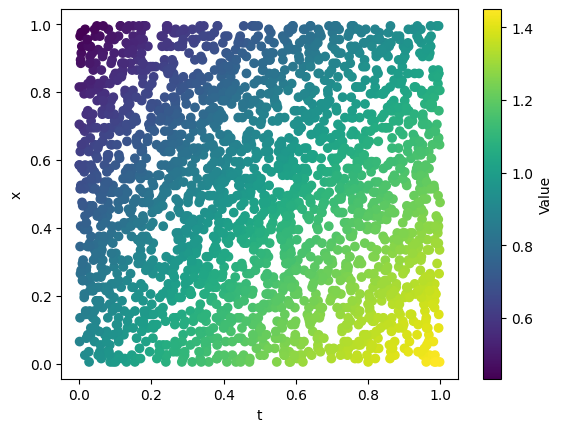

In [30]:
x_plot = X_colocacao
y_pred = G(x_plot).detach().numpy()
# y_pred = [KNN_solver(row.numpy()) for row in X_colocacao]
plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

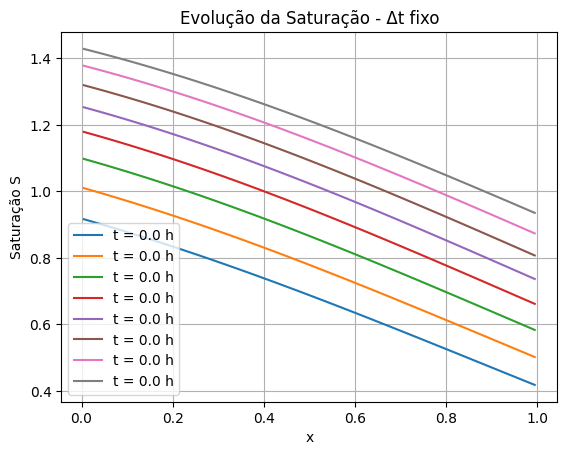

In [31]:
for t in ts[::2000]:
    X = torch.tensor(np.stack([np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = G(X).detach().cpu().numpy()
    
    plt.plot(xs, S, label=f't = {t/360:.1f} h')

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
plt.legend()
plt.grid(True)
plt.show()